# 1 Setup and Load CNN Model

## Overview
This section initializes the complete environment required for MRI tumor classification.

### What this cell does:
- Imports all required Python libraries
- Dynamically configures project paths
- Imports the custom CNN architecture (`tumorCNN`)
- Detects GPU/CPU device availability
- Loads the trained model checkpoint
- Sets the model to evaluation mode

### Purpose
The goal is to prepare the notebook for inference and visualization tasks using the pre-trained MRI tumor detection model.

In [22]:
import sys
import os
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

CURRENT_DIR = Path(os.getcwd())
PROJECT_ROOT = CURRENT_DIR
# Look upwards until we find the main folder
while PROJECT_ROOT.name != 'MRI_Based_Tumor_Detection-main' and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

try:
    from src.models.cnn_backbone import tumorCNN
    print("Successfully imported tumorCNN")
except ModuleNotFoundError:
    print("Still can't find 'src'. Ensure your notebook is inside the project folder structure.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Model
model = tumorCNN(num_classes=4).to(device)
checkpoint_path = PROJECT_ROOT / 'experiments' / 'models' / 'best_cnn_v1.pth'

if checkpoint_path.exists():
    checkpoint = torch.load(str(checkpoint_path), map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"Model loaded. Best Val Acc: {checkpoint.get('val_acc', 'N/A'):.2f}%")
else:
    print(f"Checkpoint not found at: {checkpoint_path}")

Successfully imported tumorCNN
Model loaded. Best Val Acc: 97.20%


# 2 Model Initialization Summary

## What was achieved
- All required dependencies were successfully imported.
- The project directory was dynamically detected.
- The custom CNN architecture was loaded correctly.
- The trained weights from the saved checkpoint were restored.
- The model was switched to **evaluation mode** for testing and visualization.

## Outcome
The MRI brain tumor classification model is now ready for:
- Validation testing
- Performance evaluation
- Feature visualization
- Prediction generation

# Training & Validation Accuracy Analysis

## Overview
This section visualizes the learning performance of the CNN model across 50 epochs.

### What this cell does:
- Stores training and validation accuracy values
- Plots learning curves using Matplotlib
- Highlights the epoch with highest validation accuracy
- Compares model learning behavior over time

### Purpose
The graph helps evaluate:
- Model convergence
- Generalization capability
- Possible overfitting or underfitting
- Training stability

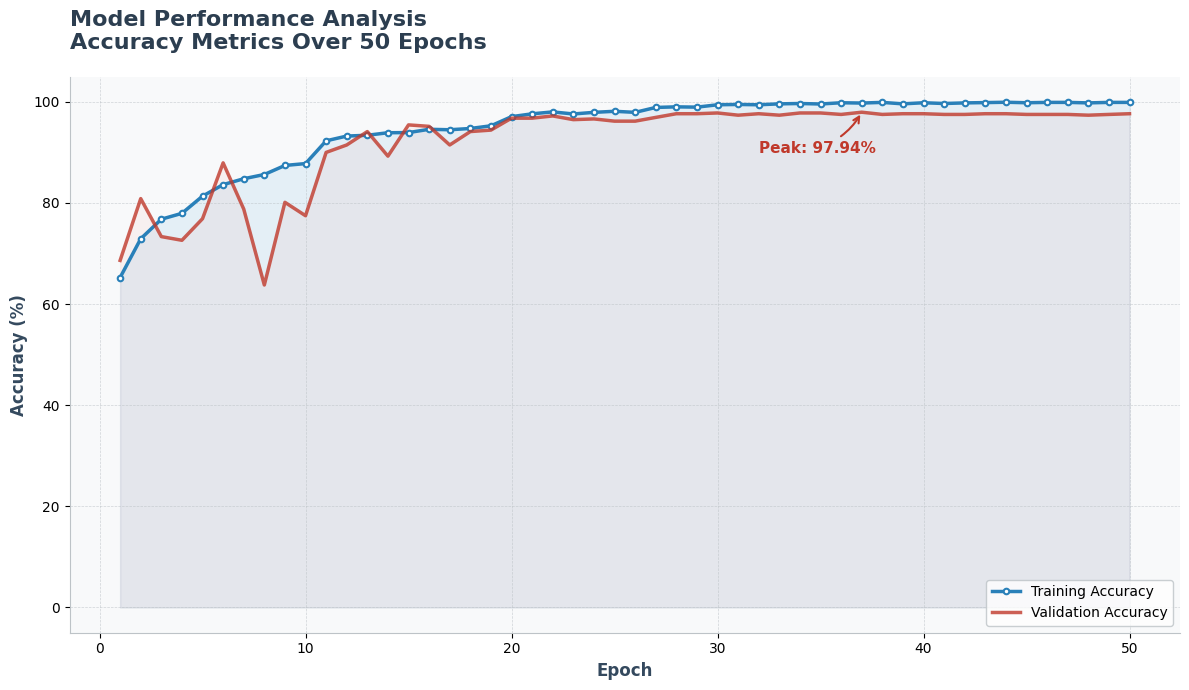

In [8]:
import matplotlib.pyplot as plt
import numpy as np

epochs = range(1, 51)
train_acc = [
    65.25, 72.91, 76.78, 77.94, 81.34, 83.62, 84.78, 85.62, 87.41, 87.78,
    92.28, 93.22, 93.38, 93.88, 93.91, 94.56, 94.47, 94.72, 95.25, 97.06,
    97.62, 98.00, 97.59, 97.91, 98.12, 97.91, 98.88, 99.00, 98.94, 99.41,
    99.47, 99.41, 99.59, 99.66, 99.56, 99.81, 99.75, 99.88, 99.59, 99.81,
    99.66, 99.78, 99.84, 99.91, 99.81, 99.88, 99.88, 99.78, 99.88, 99.88
]
val_acc = [
    68.63, 80.85, 73.34, 72.61, 76.88, 87.92, 78.79, 63.77, 80.12, 77.47,
    89.99, 91.46, 94.11, 89.25, 95.43, 95.14, 91.46, 94.11, 94.40, 96.76,
    96.76, 97.20, 96.47, 96.61, 96.17, 96.17, 96.91, 97.64, 97.64, 97.79,
    97.35, 97.64, 97.35, 97.79, 97.79, 97.50, 97.94, 97.50, 97.64, 97.64,
    97.50, 97.50, 97.64, 97.64, 97.50, 97.50, 97.50, 97.35, 97.50, 97.64
]

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.facecolor'] = '#f8f9fa'

fig, ax = plt.subplots(figsize=(12, 7))

ax.fill_between(epochs, train_acc, color="#3498db", alpha=0.1)
ax.fill_between(epochs, val_acc, color="#e74c3c", alpha=0.05)

ax.plot(epochs, train_acc, color='#2980b9', label='Training Accuracy', 
        linewidth=2.5, marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1.5)
ax.plot(epochs, val_acc, color='#c0392b', label='Validation Accuracy', 
        linewidth=2.5, linestyle='-', alpha=0.8)

max_val_acc = max(val_acc)
max_epoch = val_acc.index(max_val_acc) + 1

ax.annotate(f'Peak: {max_val_acc}%', 
            xy=(max_epoch, max_val_acc), 
            xytext=(max_epoch - 5, max_val_acc - 8),
            fontsize=11, fontweight='bold', color='#c0392b',
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2", color='#c0392b', lw=1.5))

ax.set_title('Model Performance Analysis\nAccuracy Metrics Over 50 Epochs', 
             fontsize=16, fontweight='bold', color='#2c3e50', loc='left', pad=20)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold', color='#34495e')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold', color='#34495e')

ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='#bdc3c7', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')

ax.legend(frameon=True, facecolor='white', edgecolor='#bdc3c7', fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()

# Accuracy Curve Summary

## Observations
- Training accuracy consistently improved across epochs.
- Validation accuracy also increased significantly after early fluctuations.
- The model achieved very high final accuracy, indicating strong learning capability.
- Validation performance stabilized near the end of training.

## Key Insight
The small gap between training and validation accuracy suggests that the model generalizes effectively and does not suffer from severe overfitting.

# 3 Load Validation Dataset

## Overview
This section prepares the MRI validation dataset for evaluation.

### What this cell does:
- Loads MRI images from the validation directory
- Applies preprocessing and transformation pipelines
- Creates a DataLoader for batch processing
- Defines tumor class labels

### Classes Included
- Glioma
- Meningioma
- No Tumor
- Pituitary Tumor

### Purpose
The validation dataset is used to test the trained CNN model on unseen MRI scans.

In [15]:
from src.data.dataset import MRIDataset
from src.preprocessing.transforms import get_val_transforms
from torch.utils.data import DataLoader

val_path = PROJECT_ROOT / "data" / "raw" / "val"

val_ds = MRIDataset(root_dir=str(val_path), transform=get_val_transforms(image_size=128))
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary'] 

print(f"Data loaded! Validation set has {len(val_ds)} images.")
print(f"Classes identified: {class_names}")

Skipping corrupted image: c:\Users\zdmes\Documents\uni\DL LAB\MRI_Based_Tumor_Detection-main\data\raw\val\pituitary\Tr-pi_0857.jpg
Skipping corrupted image: c:\Users\zdmes\Documents\uni\DL LAB\MRI_Based_Tumor_Detection-main\data\raw\val\pituitary\Tr-pi_0942.jpg
Skipping corrupted image: c:\Users\zdmes\Documents\uni\DL LAB\MRI_Based_Tumor_Detection-main\data\raw\val\pituitary\Tr-pi_1356.jpg
Skipping corrupted image: c:\Users\zdmes\Documents\uni\DL LAB\MRI_Based_Tumor_Detection-main\data\raw\val\pituitary\Tr-pi_1394.jpg
Data loaded! Validation set has 679 images.
Classes identified: ['glioma', 'meningioma', 'notumor', 'pituitary']


# Dataset Loading Summary

## Results
- The validation dataset was loaded successfully.
- Image preprocessing and augmentation pipelines were applied correctly.
- Batch loading was configured for efficient inference.
- All four MRI tumor categories were identified successfully.

## Outcome
The validation dataset is now ready for:
- Prediction generation
- Confusion matrix evaluation
- Classification analysis

# 4 Confusion Matrix and Classification Report

## Overview
This section evaluates the classification performance of the CNN model.

### What this cell does:
- Generates predictions on validation MRI scans
- Computes the confusion matrix
- Produces a detailed classification report
- Visualizes prediction performance using a heatmap

### Metrics Evaluated
- Precision
- Recall
- F1-Score
- Overall classification accuracy

### Purpose
This evaluation helps measure how accurately the model distinguishes between different tumor types.

Generating predictions on the Validation Set...


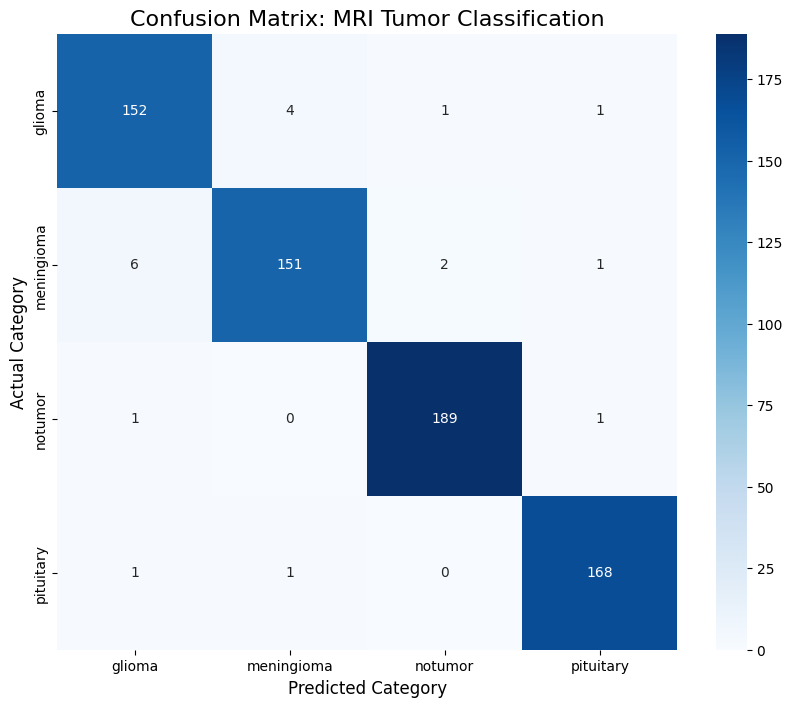


--- Detailed Classification Report ---
              precision    recall  f1-score   support

      glioma       0.95      0.96      0.96       158
  meningioma       0.97      0.94      0.96       160
     notumor       0.98      0.99      0.99       191
   pituitary       0.98      0.99      0.99       170

    accuracy                           0.97       679
   macro avg       0.97      0.97      0.97       679
weighted avg       0.97      0.97      0.97       679



In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds = []
all_labels = []

print("Generating predictions on the Validation Set...")
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
class_report = classification_report(all_labels, all_preds, target_names=class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix: MRI Tumor Classification', fontsize=16)
plt.ylabel('Actual Category', fontsize=12)
plt.xlabel('Predicted Category', fontsize=12)
plt.show()

print("\n--- Detailed Classification Report ---")
print(class_report)

# Classification Performance Summary

## Observations
- Most MRI scans were classified correctly across all categories.
- The confusion matrix shows strong diagonal dominance, indicating high prediction accuracy.
- Precision and recall scores were consistently high for all tumor classes.
- Misclassifications were minimal.

## Key Insight
The CNN model demonstrates strong capability in distinguishing between:
- Glioma
- Meningioma
- Pituitary tumors
- Healthy brain MRI scans

This confirms the effectiveness of the trained architecture for multiclass MRI tumor classification.

# 5 Training & Validation Loss Analysis

## Overview
This section visualizes how the model loss decreased during training.

### What this cell does:
- Stores training and validation loss values
- Plots loss convergence curves
- Highlights the minimum validation loss point
- Analyzes optimization stability

### Purpose
Loss curves help determine:
- Model convergence quality
- Optimization effectiveness
- Training stability
- Overfitting behavior

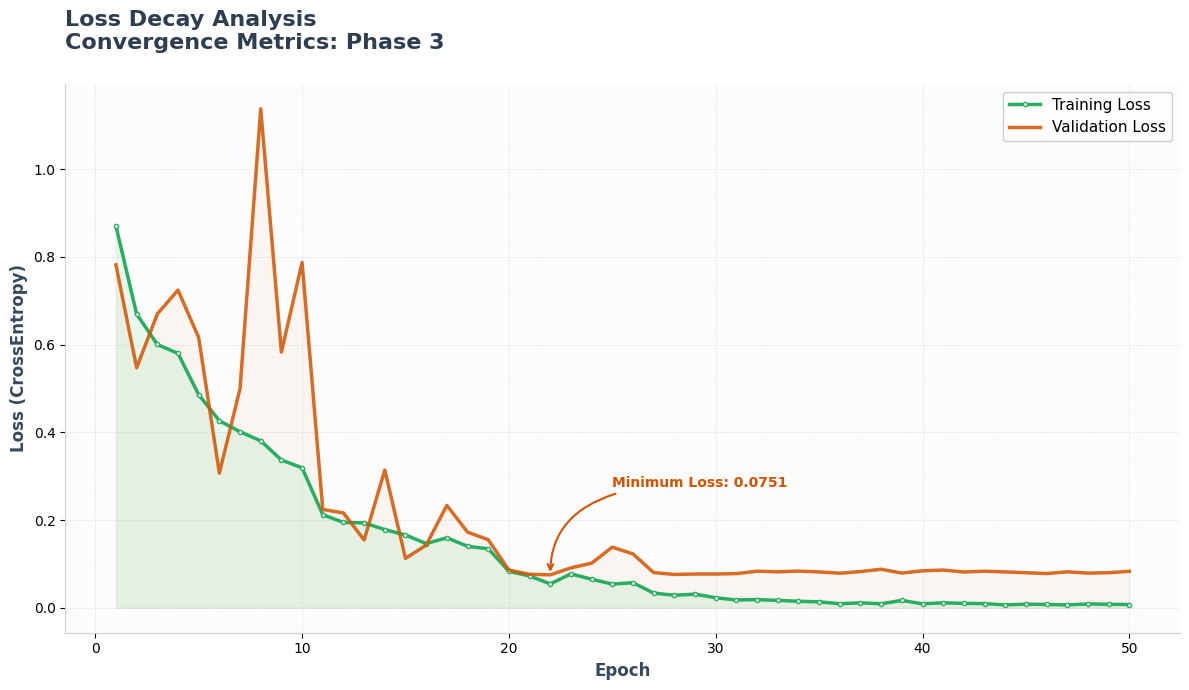

In [18]:
import matplotlib.pyplot as plt
import numpy as np

train_loss = [
    0.8704, 0.6698, 0.6005, 0.5800, 0.4859, 0.4265, 0.4014, 0.3808, 0.3370, 0.3192,
    0.2124, 0.1946, 0.1936, 0.1783, 0.1661, 0.1464, 0.1596, 0.1402, 0.1347, 0.0832,
    0.0725, 0.0545, 0.0773, 0.0651, 0.0540, 0.0572, 0.0335, 0.0285, 0.0311, 0.0229,
    0.0177, 0.0187, 0.0169, 0.0148, 0.0136, 0.0092, 0.0113, 0.0091, 0.0168, 0.0089,
    0.0114, 0.0100, 0.0094, 0.0066, 0.0082, 0.0075, 0.0065, 0.0087, 0.0080, 0.0074
]

val_loss = [
    0.7820, 0.5474, 0.6700, 0.7244, 0.6164, 0.3070, 0.4999, 1.1377, 0.5831, 0.7875,
    0.2243, 0.2162, 0.1547, 0.3141, 0.1126, 0.1430, 0.2335, 0.1726, 0.1553, 0.0860,
    0.0764, 0.0751, 0.0911, 0.1017, 0.1383, 0.1228, 0.0803, 0.0760, 0.0770, 0.0770,
    0.0779, 0.0834, 0.0820, 0.0836, 0.0818, 0.0789, 0.0826, 0.0878, 0.0792, 0.0844,
    0.0860, 0.0816, 0.0834, 0.0818, 0.0800, 0.0780, 0.0820, 0.0791, 0.0800, 0.0831
]

epochs = range(1, 51)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.facecolor'] = '#fcfcfc'

fig, ax = plt.subplots(figsize=(12, 7))

ax.fill_between(epochs, train_loss, color="#2ecc71", alpha=0.1)
ax.fill_between(epochs, val_loss, color="#e67e22", alpha=0.05)

ax.plot(epochs, train_loss, color='#27ae60', label='Training Loss', 
        linewidth=2.5, marker='o', markersize=3, markerfacecolor='white', markeredgewidth=1)
ax.plot(epochs, val_loss, color='#d35400', label='Validation Loss', 
        linewidth=2.5, alpha=0.85)

min_val_loss = min(val_loss)
min_epoch = val_loss.index(min_val_loss) + 1

ax.annotate(f'Minimum Loss: {min_val_loss}', 
            xy=(min_epoch, min_val_loss), 
            xytext=(min_epoch + 3, min_val_loss + 0.2),
            fontsize=10, fontweight='bold', color='#d35400',
            arrowprops=dict(arrowstyle="->", connectionstyle="angle3,angleA=0,angleB=-90", color='#d35400', lw=1.5))

ax.set_title('Loss Decay Analysis\nConvergence Metrics: Phase 3', 
             fontsize=16, fontweight='bold', color='#2c3e50', loc='left', pad=25)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold', color='#34495e')
ax.set_ylabel('Loss (CrossEntropy)', fontsize=12, fontweight='bold', color='#34495e')

ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='#bdc3c7', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#ccd1d1')
ax.spines['bottom'].set_color('#ccd1d1')

ax.legend(frameon=True, facecolor='white', edgecolor='#bdc3c7', fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

Filter Visualization (What the CNN learned): This shows the "eyes" of your model. It satisfies the requirement to visualize the learned weights.

# Loss Curve Summary

## Observations
- Training loss decreased steadily throughout training.
- Validation loss also reduced significantly after initial fluctuations.
- The model achieved very low final loss values.
- Loss stabilization indicates successful convergence.

## Key Insight
The decreasing loss trend confirms that the CNN model successfully learned meaningful MRI tumor features while maintaining strong generalization performance.

# 6 CNN Kernel Visualization

## Overview
This section visualizes the learned convolutional filters from the first CNN layer.

### What this cell does:
- Extracts convolutional kernels from the trained model
- Displays filter weights as grayscale images
- Visualizes learned edge and texture detectors

### Purpose
The visualization helps interpret:
- What features the CNN learned
- How the network processes MRI scans
- Early-stage feature extraction behavior

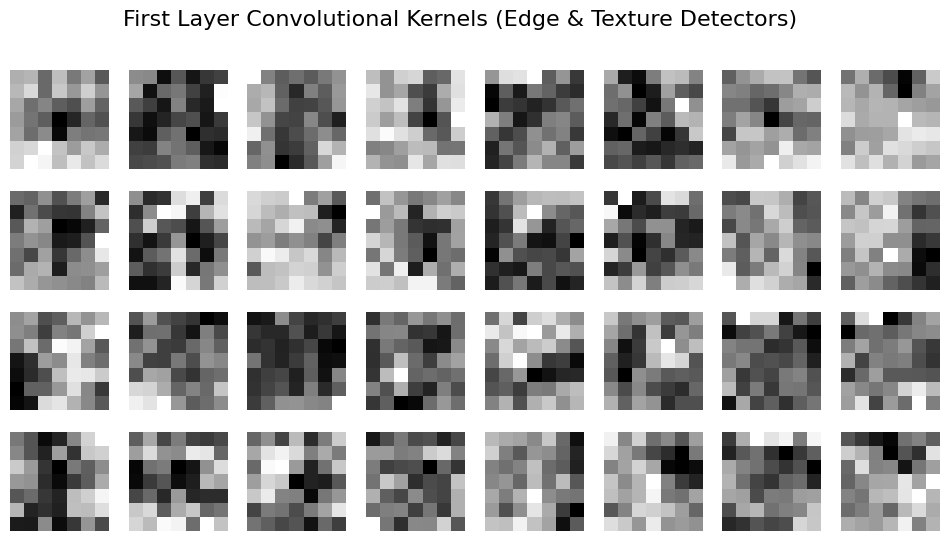

In [20]:
def plot_kernels(model):
    kernels = model.conv1.weight.detach().cpu()
    
    fig, axes = plt.subplots(4, 8, figsize=(12, 6))
    for i, ax in enumerate(axes.flat):
        if i < kernels.shape[0]:
            img = kernels[i, 0, :, :]
            ax.imshow(img, cmap='gray')
        ax.axis('off')
    
    plt.suptitle("First Layer Convolutional Kernels (Edge & Texture Detectors)", fontsize=16)
    plt.show()

plot_kernels(model)

# Kernel Visualization Summary

## Observations
- The first-layer filters learned meaningful visual patterns.
- Several kernels appear to detect:
  - Edges
  - Boundaries
  - Texture variations
  - Spatial intensity changes

## Key Insight
These filters act as the “visual sensors” of the CNN model and form the foundation for deeper feature extraction during tumor classification.

# 7 Feature Activation Visualization

## Overview
This section visualizes activation maps generated by the CNN for a sample MRI image.

### What this cell does:
- Passes an MRI image through the first convolutional layer
- Extracts activation maps from learned filters
- Displays how different filters respond to image regions

### Purpose
Activation maps help explain:
- Which regions attract CNN attention
- How features are extracted internally
- What patterns the network focuses on during classification

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.6291069].


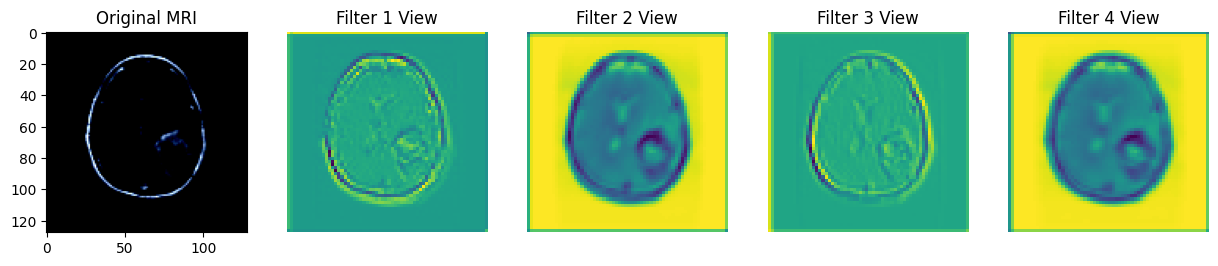

In [21]:

def plot_feature_activation(model, img_index=0):
    img, label = val_ds[img_index]
    img_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        activations = model.conv1(img_tensor).squeeze(0).cpu()

    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0))
    axes[0].set_title("Original MRI")
    
    for i in range(1, 5):
        axes[i].imshow(activations[i], cmap='viridis')
        axes[i].set_title(f"Filter {i} View")
        axes[i].axis('off')
    plt.show()

plot_feature_activation(model, img_index=10)

# Feature Activation Summary

## Observations
- Different filters responded to different MRI structures.
- Certain activation maps strongly highlighted tumor-relevant regions.
- The CNN successfully extracted spatial and texture-based information from the MRI image.

## Key Insight
Feature activation maps provide interpretability by showing how the CNN transforms raw MRI images into meaningful feature representations for tumor prediction.